In [129]:
import pandas as pd

url = "https://raw.githubusercontent.com/PriyankaDewan06/Tableau--Telco--Customer-Churn/refs/heads/main/WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [130]:
df.shape

(7043, 21)

In [131]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [132]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [133]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

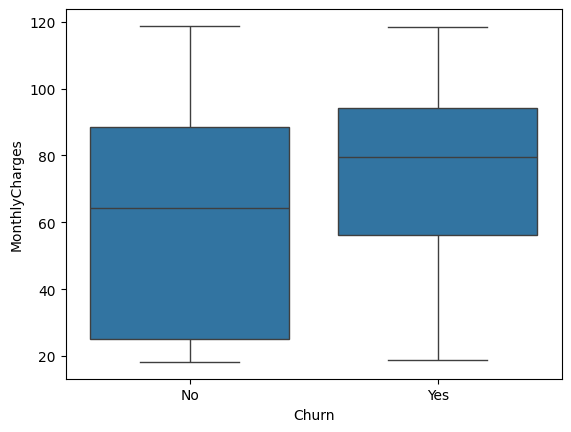

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x = "Churn", y = "MonthlyCharges", data = df)
plt.show()

In [135]:
df = df.drop(columns = ["customerID"])

In [136]:
df["Churn"] = df["Churn"].map({"Yes" : 1, "No" : 0})
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [137]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [138]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors = "coerce")
df["TotalCharges"].dtype

dtype('float64')

In [139]:
df.isna().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [140]:
df = df.dropna()
df.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [141]:
X = df.drop(columns = ["Churn"])
y = df["Churn"]

In [142]:
X_encoded = pd.get_dummies(X, drop_first = True)
X_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [143]:
X_encoded.shape

(7032, 30)

In [144]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size = 0.25, random_state = 42, stratify = y
)

In [145]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [146]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(X_train_scaler, y_train)
y_pred = log_reg.predict(X_test_scaler)

In [147]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy

0.8077360637087599

In [148]:
from sklearn.metrics import confusion_matrix

con_mat = confusion_matrix(y_test, y_pred)
con_mat

array([[1150,  141],
       [ 197,  270]])

In [149]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1291
           1       0.66      0.58      0.62       467

    accuracy                           0.81      1758
   macro avg       0.76      0.73      0.74      1758
weighted avg       0.80      0.81      0.80      1758



In [150]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators = 200,
    random_state = 42
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [151]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[1152,  139],
       [ 237,  230]])

In [152]:
con_rf = accuracy_score(y_test, y_pred_rf)
con_rf

0.7861205915813424

In [153]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1291
           1       0.62      0.49      0.55       467

    accuracy                           0.79      1758
   macro avg       0.73      0.69      0.70      1758
weighted avg       0.77      0.79      0.78      1758



In [ ]:
y_proba_log = log_reg.predict_proba(X_test_scaler)[:, 1]
y_proba_03 = (y_proba_log >= 0.3).astype(int)

In [156]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_proba_03 )

array([[960, 331],
       [108, 359]])

In [162]:
print(classification_report(y_test, y_proba_03))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1291
           1       0.52      0.77      0.62       467

    accuracy                           0.75      1758
   macro avg       0.71      0.76      0.72      1758
weighted avg       0.80      0.75      0.76      1758



In [157]:
thresholds = [0.5, 0.4, 0.3, 0.2]

for t in thresholds:
  y_pred_t = (y_proba_log>= t).astype(int)
  cm = confusion_matrix(y_test, y_pred_t)
  print(f"Thresholds: {t}" )
  print(cm)

Thresholds: 0.5
[[1150  141]
 [ 197  270]]
Thresholds: 0.4
[[1061  230]
 [ 142  325]]
Thresholds: 0.3
[[960 331]
 [108 359]]
Thresholds: 0.2
[[819 472]
 [ 68 399]]


In [158]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(y_test, y_proba_log)
auc

0.8400066678056118

In [159]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)

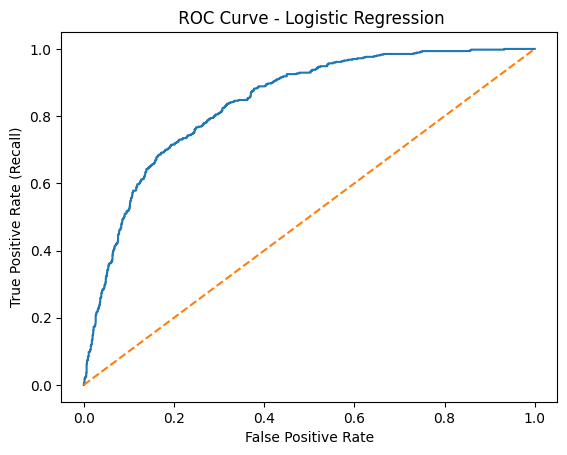

In [160]:

import matplotlib.pyplot as plt

plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], linestyle = "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title(" ROC Curve - Logistic Regression")
plt.show()